## Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os
import joblib


## Carga de datos

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/TFG/data_processed/"
os.makedirs(base_path, exist_ok=True)

train_df = pd.read_csv(base_path + "train_clean.csv")
test_df = pd.read_csv(base_path + "test_augmented.csv")

feature_cols = joblib.load(base_path + "feature_cols.pkl")
base_features = joblib.load(base_path + "base_features.pkl")
derived_features = joblib.load(base_path + "derived_features.pkl")
domain_features = joblib.load(base_path + "domain_features.pkl")

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Total features:", len(feature_cols))
print("Base:", len(base_features))
print("Derived:", len(derived_features))
print("Domain:", len(domain_features))

Train: (1228043, 37)
Test: (312778, 39)
Total features: 27
Base: 13
Derived: 8
Domain: 6


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1228043 entries, 0 to 1228042
Data columns (total 37 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   segment_id                1228043 non-null  int64  
 1   MMSI                      1228043 non-null  int64  
 2   trajectory_id             1228043 non-null  int64  
 3   speed_mean                1228043 non-null  float64
 4   speed_std                 1228043 non-null  float64
 5   speed_max                 1228043 non-null  float64
 6   delta_course_mean         1228043 non-null  float64
 7   delta_course_max          1228043 non-null  float64
 8   turning_rate_mean         1228043 non-null  float64
 9   turning_rate_max          1228043 non-null  float64
 10  acceleration_mean         1228043 non-null  float64
 11  acceleration_max          1228043 non-null  float64
 12  delta_t_mean              1228043 non-null  float64
 13  delta_t_max               1

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312778 entries, 0 to 312777
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   segment_id                312778 non-null  int64  
 1   MMSI                      312778 non-null  int64  
 2   trajectory_id             312778 non-null  int64  
 3   speed_mean                312778 non-null  float64
 4   speed_std                 312778 non-null  float64
 5   speed_max                 312778 non-null  float64
 6   delta_course_mean         312778 non-null  float64
 7   delta_course_max          312778 non-null  float64
 8   turning_rate_mean         312778 non-null  float64
 9   turning_rate_max          312778 non-null  float64
 10  acceleration_mean         312778 non-null  float64
 11  acceleration_max          312778 non-null  float64
 12  delta_t_mean              312778 non-null  float64
 13  delta_t_max               312778 non-null  f

Selección de features, sólo nos interesa el comportamiento

In [ ]:
features_full = feature_cols

features_reduced = [
    "speed_mean",
    "delta_course_mean",
    "turning_rate_mean",
    "distance_km",
    "duration",
    "ais_gap",
    "slow_motion",
    "high_speed_flag",
    "low_distance_flag"
]

feature_sets = {
    "full": features_full,
    "base_only": base_features,
    "base_derived": base_features + derived_features,
    "domain_only": domain_features,
    "reduced": features_reduced
}

print("Feature sets definidos:")
for name, fs in feature_sets.items():
    print(f"{name}: {len(fs)} features")

Feature sets definidos:
full: 27 features
base_only: 13 features
base_derived: 21 features
domain_only: 6 features
reduced: 9 features


En esta fase se comparan varios subconjuntos de variables para estudiar cómo cambia el rendimiento del detector:

- **full**: todas las variables disponibles.
- **base_only**: solo variables cinemáticas y temporales base.
- **base_derived**: variables base y derivadas de comportamiento.
- **domain_only**: indicadores inspirados en dominio.
- **reduced**: subconjunto compacto e interpretable.

Esto permite realizar una selección de modelo más sistemática y justificar mejor la configuración final.

Escalado

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train = train_df[features_full].copy()
X_test = test_df[features_full].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (1228043, 27)
X_test_scaled: (312778, 27)


## Isolation Forest (baseline)

Se trata de un modelo no supervisado que es capaz de modelar comportamiento normal sin necesidad de etiquetas y con gran eficiencia computacional en datasets de gran tamaño.

**Hiperparámetros:**
- n_estimators: número de árboles en el bosque, cuantos más árboles, más estabilidad
- contamination: proporción esperada de anomalías. En nuestro caso, con el data augmentation tenemos un 6% de anomalías en test. Este parámetro permite al modelo establecer un umbral de decisión coherente con la distribución esperada de datos anómalos.
- random_state: semilla aleatoria
- n_jobs: uso de todos los núcleos disponibles

In [ ]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.06,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled)

IsolationForest(contamination=0.06, n_estimators=200, n_jobs=-1,
                random_state=42)

Predicciones

In [ ]:
test_df["if_score_raw"] = model.decision_function(X_test_scaled)
test_df["if_prediction_raw"] = model.predict(X_test_scaled)

# 1 = anomalía, 0 = normal
test_df["if_flag_raw"] = (test_df["if_prediction_raw"] == -1).astype(int)

test_df[["if_score_raw", "if_flag_raw", "anomaly_type", "is_synthetic"]].head()

,if_score_raw,if_flag_raw,anomaly_type,is_synthetic
0,0.011195,0,normal,0
1,0.020313,0,normal,0
2,-0.006887,1,normal,0
3,0.020954,0,normal,0
4,0.074886,0,normal,0


Evaluación global

In [ ]:
print("Distribución predicciones:")
print(test_df["if_flag_raw"].value_counts())

print("\nDistribución real:")
print(test_df["is_synthetic"].value_counts())

Distribución predicciones:
if_flag_raw
0    294351
1     18427
Name: count, dtype: int64

Distribución real:
is_synthetic
0    295078
1     17700
Name: count, dtype: int64


El modelo presenta dificultades para distinguir entre comportamientos normales y anomalías sintéticas, especialmente en aquellos casos donde las desviaciones son sutiles.

Evaluación por tipo

In [ ]:
results = test_df.groupby("anomaly_type")["if_flag_raw"].mean().sort_values(ascending=False)
results

,if_flag_raw
anomaly_type,
zigzag_anomaly,0.089831
route_deviation,0.087119
speed_anomaly,0.082712
ais_gap_anomaly,0.077966
loitering_like,0.069492
normal,0.057808
close_approach,0.056949


El modelo detecta de una manera muy clara speed anomaly, por el otro lado, los comportamientos normales los detecta casi al azar. El modelo tiene dificultades para capturar comportamientos complejos o dependientes del contexto.

### Métricas

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = test_df["is_synthetic"]
y_pred = test_df["if_flag_raw"]

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification report:")
print(classification_report(y_true, y_pred, zero_division=0))

Confusion matrix:
[[278020  17058]
 [ 16331   1369]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    295078
           1       0.07      0.08      0.08     17700

    accuracy                           0.89    312778
   macro avg       0.51      0.51      0.51    312778
weighted avg       0.90      0.89      0.89    312778



El modelo detecta el 7% de las anomalías reales y además solo el 7% de lo que detecta es correcto. Esto es muy bajo. Que el accuracy sea alto no significa que el modelo sea bueno, eso se debe a que identifica bien a los comportamientos normales, que no es nuestro enfoque.

## Estrategias de mejora

El modelo inicial mostró un rendimiento limitado, lo que motivó la exploración de distintas estrategias de mejora, incluyendo el ajuste del umbral, la modificación del parámetro de contaminación y la selección de variables.

A continuación se evaluarán tres estrategias de mejora:
1. Ajuste del umbral de decisión (threshold tuning)
2. Modificación del parámetro contamination
3. Reducción del conjunto de variables

Para evitar data leakage, el conjunto test_augmented se dividirá en:
- validation: para comparar alternativas
- holdout: para evaluación final

In [ ]:
from sklearn.model_selection import train_test_split

validation_df, holdout_df = train_test_split(
    test_df,
    test_size=0.5,
    random_state=42,
    stratify=test_df["anomaly_type"]
)

print("Validation:", validation_df.shape)
print("Holdout:", holdout_df.shape)

print("\nValidation anomaly types:")
print(validation_df["anomaly_type"].value_counts())

print("\nHoldout anomaly types:")
print(holdout_df["anomaly_type"].value_counts())

Validation: (156389, 42)
Holdout: (156389, 42)

Validation anomaly types:
anomaly_type
normal             147539
loitering_like       1475
close_approach       1475
ais_gap_anomaly      1475
zigzag_anomaly       1475
speed_anomaly        1475
route_deviation      1475
Name: count, dtype: int64

Holdout anomaly types:
anomaly_type
normal             147539
speed_anomaly        1475
close_approach       1475
ais_gap_anomaly      1475
route_deviation      1475
zigzag_anomaly       1475
loitering_like       1475
Name: count, dtype: int64


El conjunto `test_augmented` se divide en dos partes:

- **validation_df**: para comparar configuraciones y seleccionar el detector.
- **holdout_df**: para evaluar la configuración final sin reutilizar directamente el conjunto de validación.

De este modo, aunque las anomalías sean sintéticas, se mantiene una separación interna razonable entre ajuste y evaluación final.

In [ ]:
print("Feature sets disponibles:")
for name, fs in feature_sets.items():
    print(f"{name}: {len(fs)} features")

Feature sets disponibles:
full: 27 features
base_only: 13 features
base_derived: 21 features
domain_only: 6 features
reduced: 9 features



Entrena Isolation Forest sobre train_df y puntúa eval_df.

Devuelve el dataframe evaluado, el modelo y el scaler.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def fit_iforest_and_score(train_df, eval_df, features, contamination=0.06, random_state=42):

    X_train = train_df[features].copy()
    X_eval = eval_df[features].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_train_scaled)

    scores = model.decision_function(X_eval_scaled)
    pred_default = (model.predict(X_eval_scaled) == -1).astype(int)

    out = eval_df.copy()
    out["anomaly_score"] = scores
    out["pred_default"] = pred_default

    return out, model, scaler

Función auxiliar de métricas

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

def compute_metrics(df, pred_col="pred_default"):
    y_true = df["is_synthetic"]
    y_pred = df[pred_col]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### 1. Ajustar threshold

In [ ]:
val_base, model_base, scaler_base = fit_iforest_and_score(
    train_df=train_df,
    eval_df=validation_df,
    features=features_full,
    contamination=0.06,
    random_state=42
)

print("Métricas baseline en validation:")
print(compute_metrics(val_base, pred_col="pred_default"))

Métricas baseline en validation:
{'precision': 0.07367058569733578, 'recall': 0.07717514124293785, 'f1': 0.07538215330279786}


Probamos los percentiles del score

In [ ]:
threshold_results = []

for pct in [1, 2, 3, 4, 5, 6, 7, 8, 10]:
    thr = np.percentile(val_base["anomaly_score"], pct)

    temp = val_base.copy()
    temp["pred_custom"] = (temp["anomaly_score"] < thr).astype(int)

    metrics = compute_metrics(temp, pred_col="pred_custom")
    metrics["percentile"] = pct
    metrics["threshold"] = thr

    threshold_results.append(metrics)

threshold_results_df = pd.DataFrame(threshold_results).sort_values("f1", ascending=False)
threshold_results_df

,precision,recall,f1,percentile,threshold
8,0.080568,0.142373,0.102903,10,0.039696
7,0.078245,0.110621,0.091658,8,0.023981
6,0.076361,0.094463,0.084453,7,0.013363
5,0.074062,0.078531,0.076231,6,0.000890
4,0.071100,0.062825,0.066707,5,-0.013940
3,0.072251,0.051073,0.059844,4,-0.029884
2,0.074169,0.039322,0.051396,3,-0.049655
1,0.077046,0.027232,0.040240,2,-0.073284
0,0.081202,0.014350,0.024390,1,-0.107359


Escogemos el mejor threshold

In [ ]:
best_threshold_row = threshold_results_df.iloc[0]

best_pct = best_threshold_row["percentile"]
best_thr = best_threshold_row["threshold"]

print("Mejor percentile:", best_pct)
print("Mejor threshold:", best_thr)
print(best_threshold_row)

Mejor percentile: 10.0
Mejor threshold: 0.03969639284268676
precision      0.080568
recall         0.142373
f1             0.102903
percentile    10.000000
threshold      0.039696
Name: 8, dtype: float64


### 2. Cambiar la contaminación

In [ ]:
contamination_results = []

for cont in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]:
    val_temp, _, _ = fit_iforest_and_score(
        train_df=train_df,
        eval_df=validation_df,
        features=features_full,
        contamination=cont,
        random_state=42
    )

    metrics = compute_metrics(val_temp, pred_col="pred_default")
    metrics["contamination"] = cont

    contamination_results.append(metrics)

contamination_results_df = pd.DataFrame(contamination_results).sort_values("f1", ascending=False)
contamination_results_df

,precision,recall,f1,contamination
5,0.073671,0.077175,0.075382,0.06
4,0.071021,0.061921,0.066160,0.05
3,0.072600,0.050508,0.059572,0.04
2,0.074389,0.039548,0.051641,0.03
1,0.075651,0.027910,0.040776,0.02
0,0.081324,0.016384,0.027274,0.01


In [ ]:
best_cont_row = contamination_results_df.iloc[0]
best_cont = best_cont_row["contamination"]

print("Mejor contamination:", best_cont)
print(best_cont_row)

Mejor contamination: 0.06
precision        0.073671
recall           0.077175
f1               0.075382
contamination    0.060000
Name: 5, dtype: float64


### 3. Reducir features

In [ ]:
feature_results = []

for feature_name, feature_set in feature_sets.items():

    val_temp, _, _ = fit_iforest_and_score(
        train_df=train_df,
        eval_df=validation_df,
        features=feature_set,
        contamination=0.06,
        random_state=42
    )

    metrics = compute_metrics(val_temp, pred_col="pred_default")
    metrics["feature_set"] = feature_name
    metrics["n_features"] = len(feature_set)

    feature_results.append(metrics)

feature_results_df = pd.DataFrame(feature_results).sort_values("f1", ascending=False)
feature_results_df

,precision,recall,f1,feature_set,n_features
4,0.128784,0.141808,0.134983,reduced,9
3,0.088141,0.096158,0.091975,domain_only,6
2,0.078189,0.083729,0.080864,base_derived,21
1,0.079177,0.082147,0.080634,base_only,13
0,0.073671,0.077175,0.075382,full,27


In [ ]:
best_feature_row = feature_results_df.iloc[0]
best_feature_set_name = best_feature_row["feature_set"]

if best_feature_set_name == "full":
    best_features = features_full
else:
    best_features = features_reduced

print("Mejor feature set:", best_feature_set_name)
print(best_feature_row)

Mejor feature set: reduced
precision      0.128784
recall         0.141808
f1             0.134983
feature_set     reduced
n_features            9
Name: 4, dtype: object


La reducción del espacio de características mejora significativamente el rendimiento del modelo, lo que sugiere que la presencia de variables redundantes o ruidosas dificultaba la capacidad del modelo para identificar patrones anómalos.

**Justificación de la reducción de variables**

La reducción del espacio de características no se realizó únicamente en base al F1-score,
sino también buscando disminuir redundancia, ruido y multicolinealidad.

Las 9 variables reducidas se eligieron porque representan tres bloques con interpretación clara:

1. Cinemática básica:
   - speed_mean
   - distance_km
   - duration

2. Dinámica de trayectoria:
   - delta_course_mean
   - turning_rate_mean

3. Irregularidad y heurísticas marítimas:
   - ais_gap
   - slow_motion
   - high_speed_flag
   - low_distance_flag

Además, se añade un análisis auxiliar de importancia de variables con Random Forest
para comprobar si estas variables conservan capacidad explicativa.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X_val_full = validation_df[features_full].copy()
y_val = validation_df["is_synthetic"].copy()

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_val_full, y_val)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=features_full
).sort_values(ascending=False)

feature_importance.head(15)

,0
duration,0.191605
high_speed_flag,0.122300
ais_gap,0.068077
delta_course_mean,0.065409
course_instability,0.057504
delta_t_mean,0.055659
avg_speed_kmh,0.054026
delta_course_max,0.049215
points_density,0.048455
distance_km,0.042647


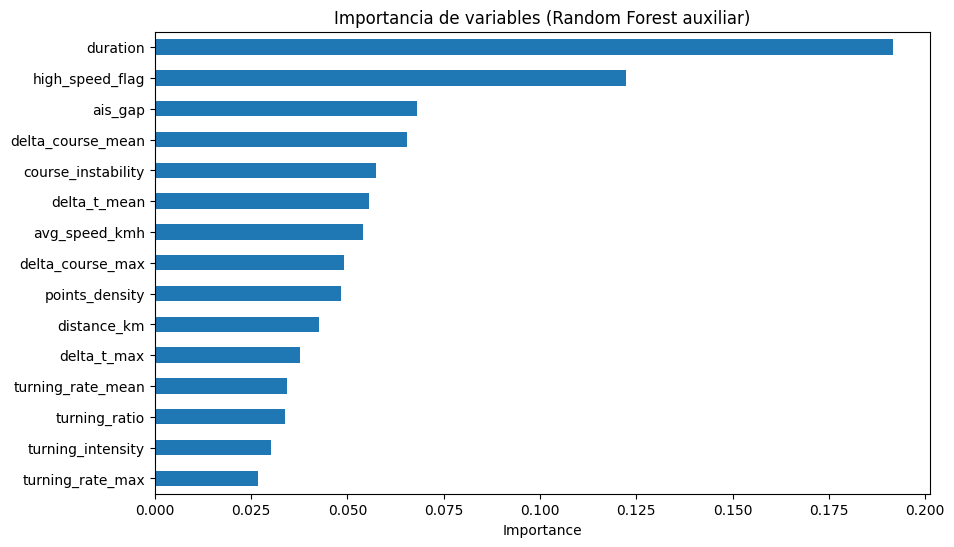

In [ ]:
plt.figure(figsize=(10,6))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Importancia de variables (Random Forest auxiliar)")
plt.xlabel("Importance")
plt.show()

La selección de variables no se basó exclusivamente en métricas de importancia supervisadas, sino en un enfoque combinado que integra:
mejora empírica del rendimiento del modelo,
interpretabilidad física de las variables en el dominio marítimo,
y reducción de redundancia y ruido.

In [ ]:
print("Features full:", features_full)
print("\nFeatures reduced:", features_reduced)

Features full: ['speed_mean', 'speed_std', 'speed_max', 'delta_course_mean', 'delta_course_max', 'turning_rate_mean', 'turning_rate_max', 'acceleration_mean', 'acceleration_max', 'delta_t_mean', 'delta_t_max', 'distance_km', 'duration', 'course_instability', 'speed_cv', 'turning_intensity', 'speed_variation', 'avg_speed_kmh', 'ais_gap', 'acceleration_instability', 'turning_ratio', 'slow_motion', 'high_speed_flag', 'low_distance_flag', 'points_density', 'erratic_motion_flag', 'stop_like_flag']

Features reduced: ['speed_mean', 'delta_course_mean', 'turning_rate_mean', 'distance_km', 'duration', 'ais_gap', 'slow_motion', 'high_speed_flag', 'low_distance_flag']


### Comparación final de estrategias

In [ ]:
comparison = pd.DataFrame([
    {
        "option": "A_threshold",
        "precision": best_threshold_row["precision"],
        "recall": best_threshold_row["recall"],
        "f1": best_threshold_row["f1"]
    },
    {
        "option": "B_contamination",
        "precision": best_cont_row["precision"],
        "recall": best_cont_row["recall"],
        "f1": best_cont_row["f1"]
    },
    {
        "option": "C_features",
        "precision": best_feature_row["precision"],
        "recall": best_feature_row["recall"],
        "f1": best_feature_row["f1"]
    }
]).sort_values("f1", ascending=False)

comparison

,option,precision,recall,f1
2,C_features,0.128784,0.141808,0.134983
0,A_threshold,0.080568,0.142373,0.102903
1,B_contamination,0.073671,0.077175,0.075382


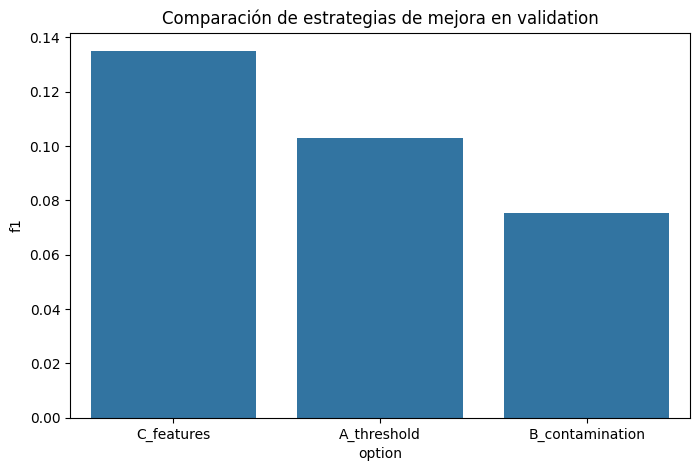

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x="option", y="f1")
plt.title("Comparación de estrategias de mejora en validation")
plt.show()

Elegir la ganadora

In [ ]:
best_option = comparison.iloc[0]["option"]
print("Mejor estrategia:", best_option)

Mejor estrategia: C_features


### Aplicación de la mejor estrategia

In [ ]:
if best_option == "A_threshold":
    final_features = features_full
    final_cont = 0.06

    holdout_scored, final_model, final_scaler = fit_iforest_and_score(
        train_df=train_df,
        eval_df=holdout_df,
        features=final_features,
        contamination=final_cont,
        random_state=42
    )

    holdout_scored["pred_final"] = (holdout_scored["anomaly_score"] < best_thr).astype(int)

elif best_option == "B_contamination":
    final_features = features_full
    final_cont = best_cont

    holdout_scored, final_model, final_scaler = fit_iforest_and_score(
        train_df=train_df,
        eval_df=holdout_df,
        features=final_features,
        contamination=final_cont,
        random_state=42
    )

    holdout_scored["pred_final"] = holdout_scored["pred_default"]

else:
    final_features = best_features
    final_cont = 0.06

    holdout_scored, final_model, final_scaler = fit_iforest_and_score(
        train_df=train_df,
        eval_df=holdout_df,
        features=final_features,
        contamination=final_cont,
        random_state=42
    )

    holdout_scored["pred_final"] = holdout_scored["pred_default"]

Métricas finales

In [ ]:
print("Confusion matrix:")
print(confusion_matrix(holdout_scored["is_synthetic"], holdout_scored["pred_final"]))

print("\nClassification report:")
print(classification_report(
    holdout_scored["is_synthetic"],
    holdout_scored["pred_final"],
    zero_division=0
))

Confusion matrix:
[[139097   8442]
 [  7614   1236]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95    147539
           1       0.13      0.14      0.13      8850

    accuracy                           0.90    156389
   macro avg       0.54      0.54      0.54    156389
weighted avg       0.90      0.90      0.90    156389



Se detecta 14% de las anomalías reales y 13% son realmente anómalas. Isolation Forest lo que identifica es lo que es raro estadísticamente, no sabe lo que es una anomalía.

In [ ]:
holdout_results_by_type = holdout_scored.groupby("anomaly_type")["pred_final"].mean().sort_values(ascending=False)
holdout_results_by_type

,pred_final
anomaly_type,
close_approach,0.171525
loitering_like,0.167458
speed_anomaly,0.151186
ais_gap_anomaly,0.138305
zigzag_anomaly,0.120000
route_deviation,0.089492
normal,0.057219


Este modelo, detecta más anom alías que comportamientos normales. El modelo no clasifica perfectamente pero ordena el riesgo.

El modelo no se utiliza como clasificador binario, sino como un sistema de ranking de riesgo, donde los segmentos con mayor puntuación son considerados más sospechosos y priorizados para análisis posterior.


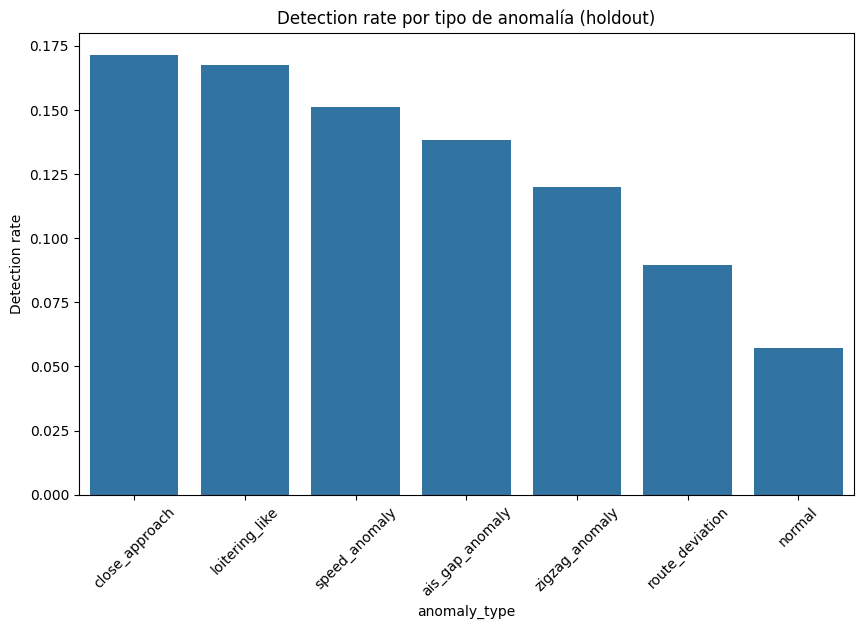

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=holdout_results_by_type.index, y=holdout_results_by_type.values)
plt.xticks(rotation=45)
plt.ylabel("Detection rate")
plt.title("Detection rate por tipo de anomalía (holdout)")
plt.show()

In [ ]:
type_detection_table = pd.crosstab(
    holdout_scored["anomaly_type"],
    holdout_scored["pred_final"],
    normalize="index"
)

type_detection_table.columns = ["not_detected", "detected"]
type_detection_table

,not_detected,detected
anomaly_type,,
ais_gap_anomaly,0.861695,0.138305
close_approach,0.828475,0.171525
loitering_like,0.832542,0.167458
normal,0.942781,0.057219
route_deviation,0.910508,0.089492
speed_anomaly,0.848814,0.151186
zigzag_anomaly,0.880000,0.120000


In [ ]:
analysis_cols = [
    "speed_mean",
    "delta_course_mean",
    "turning_rate_mean",
    "distance_km",
    "duration",
    "ais_gap"
]

holdout_scored.groupby("anomaly_type")[analysis_cols].mean()

,speed_mean,delta_course_mean,turning_rate_mean,distance_km,duration,ais_gap
anomaly_type,,,,,,
ais_gap_anomaly,1.285391,16.448902,0.172175,0.997802,761.134237,3.192441
close_approach,0.563925,16.791024,0.254705,0.268510,1096.366145,1.445491
loitering_like,0.632461,15.294893,0.170551,0.970852,1104.213481,1.434583
normal,1.315870,16.036696,0.172779,1.229335,759.420662,1.454590
route_deviation,1.270924,24.511200,0.252892,0.761304,760.685424,1.463893
speed_anomaly,2.115310,17.185744,0.189116,0.829008,761.440000,1.460222
zigzag_anomaly,1.290919,30.153518,0.343394,1.300605,760.530169,1.468230


## Benchmark automatizado

Tras optimizar Isolation Forest mediante ajuste de threshold, contamination y subconjuntos de variables, se realiza una comparación automatizada entre varios detectores no supervisados.

El objetivo es determinar qué algoritmo se adapta mejor al problema de detección de anomalías marítimas en el conjunto de validación controlada.

In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 4.8 MB/s eta 0:00:00


En este TFG se opta exclusivamente por métodos no supervisados por las siguientes razones:

- Los datos AIS etiquetados son escasos y costosos de obtener en el dominio marítimo.
- Las anomalías marítimas son eventos raros y difíciles de etiquetar manualmente.
- Los métodos no supervisados permiten detectar patrones anómalos desconocidos a priori.
- Este enfoque se alinea con la literatura reciente (Riveiro et al., 2023; Chen & Wang, 2024).

El benchmark propuesto permite identificar el detector no supervisado más adecuado para
datos AIS sin necesidad de datos etiquetados durante el entrenamiento.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from pyod.models.ecod import ECOD
from pyod.models.hbos import HBOS
from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
import time

def evaluate_detector(train_df, eval_df, features, model_name, random_state=42, **kwargs):
    X_train = train_df[features].copy()
    X_eval = eval_df[features].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    # Medir tiempo
    start_time = time.time()

    if model_name == "IF":
        model = IsolationForest(
            n_estimators=kwargs.get("n_estimators", 200),
            contamination=kwargs.get("contamination", 0.06),
            random_state=random_state,
            n_jobs=-1
        )
        model.fit(X_train_scaled)
        score = -model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == -1).astype(int)

    elif model_name == "LOF":
        model = LocalOutlierFactor(
            n_neighbors=kwargs.get("n_neighbors", 20),
            contamination=kwargs.get("contamination", 0.06),
            novelty=True
        )
        model.fit(X_train_scaled)
        score = -model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == -1).astype(int)

    elif model_name == "OCSVM":
        model = OneClassSVM(
            kernel=kwargs.get("kernel", "rbf"),
            nu=kwargs.get("nu", 0.05),
            gamma=kwargs.get("gamma", "scale")
        )
        model.fit(X_train_scaled)
        score = -model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == -1).astype(int)


    elif model_name == "ECOD":
        model = ECOD(
            contamination=kwargs.get("contamination", 0.06)
        )
        model.fit(X_train_scaled)
        score = model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == 1).astype(int)

    elif model_name == "HBOS":
        model = HBOS(
            n_bins=kwargs.get("n_bins", 10),
            contamination=kwargs.get("contamination", 0.06)
        )
        model.fit(X_train_scaled)
        score = model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == 1).astype(int)

    elif model_name == "ABOD":
        model = ABOD(
            contamination=kwargs.get("contamination", 0.06),
            n_neighbors=kwargs.get("n_neighbors", 10)
        )
        model.fit(X_train_scaled)
        score = model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == 1).astype(int)

    elif model_name == "CBLOF":
        model = CBLOF(
            contamination=kwargs.get("contamination", 0.06),
            n_clusters=kwargs.get("n_clusters", 8)
        )
        model.fit(X_train_scaled)
        score = model.decision_function(X_eval_scaled)
        pred = (model.predict(X_eval_scaled) == 1).astype(int)

    else:
        raise ValueError(f"Modelo no soportado: {model_name}")

    train_time = time.time() - start_time

    temp = eval_df.copy()
    temp["detector_score"] = score
    temp["detector_pred"] = pred

    metrics = compute_metrics(temp, pred_col="detector_pred")
    metrics["train_time"] = train_time

    return temp, metrics, model, scaler

El benchmark permite probar de forma automática 12 combinaciones diferentes de algoritmos y conjuntos de características sin necesidad de intervención manual, lo que garantiza la reproducibilidad y eficiencia del proceso de evaluación.

Todos los modelos son evaluados bajo las mismas condiciones, utilizando los mismos datos de entrenamiento y validación, así como las mismas métricas de rendimiento, lo que asegura una comparación justa y objetiva entre los distintos detectores.

In [ ]:
benchmark_results = []

benchmark_configs = [
    # CORE BENCHMARK
    {"model_name": "IF", "features": "full", "contamination": 0.06, "n_estimators": 200},
    {"model_name": "IF", "features": "reduced", "contamination": 0.06, "n_estimators": 200},
    {"model_name": "IF", "features": "base_only", "contamination": 0.06},

    {"model_name": "LOF", "features": "reduced", "contamination": 0.06, "n_neighbors": 20},

    {"model_name": "OCSVM", "features": "reduced", "nu": 0.05, "kernel": "rbf", "gamma": "scale"},

    {"model_name": "ECOD", "features": "full", "contamination": 0.06},
    {"model_name": "ECOD", "features": "reduced", "contamination": 0.06},

    {"model_name": "HBOS", "features": "full", "contamination": 0.06, "n_bins": 10},
    {"model_name": "HBOS", "features": "reduced", "contamination": 0.06, "n_bins": 10},

    # EXTENDED / EXPLORATORY
    {"model_name": "LOF", "features": "full", "contamination": 0.06, "n_neighbors": 20},
    {"model_name": "ABOD", "features": "reduced", "contamination": 0.06, "n_neighbors": 10},
    {"model_name": "CBLOF", "features": "reduced", "contamination": 0.06, "n_clusters": 8},
]

print(f"Ejecutando benchmark con {len(benchmark_configs)} configuraciones...\n")

for idx, cfg in enumerate(benchmark_configs, 1):
    feature_set = feature_sets[cfg["features"]]

    print(f"[{idx}/{len(benchmark_configs)}] Probando {cfg['model_name']} - {cfg['features']}...")

    try:
        _, metrics, _, _ = evaluate_detector(
            train_df=train_df,
            eval_df=validation_df,
            features=feature_set,
            model_name=cfg["model_name"],
            random_state=42,
            **{k: v for k, v in cfg.items() if k not in ["model_name", "features"]}
        )

        row = metrics.copy()
        row.update(cfg)
        row["n_features"] = len(feature_set)
        benchmark_results.append(row)

        print(
            f"  ✓ F1: {metrics['f1']:.4f} | "
            f"Precision: {metrics['precision']:.4f} | "
            f"Recall: {metrics['recall']:.4f} | "
            f"Time: {metrics['train_time']:.2f}s"
        )

    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        continue

benchmark_results_df = pd.DataFrame(benchmark_results).sort_values("f1", ascending=False)
benchmark_results_df

Ejecutando benchmark con 12 configuraciones...



NameError: name 'feature_sets' is not defined

**1. DETECTORES PRINCIPALES**

  1.1. Isolation Forest (IF)

Isolation Forest (Liu et al., 2008) es uno de los métodos más utilizados en detección de anomalías no
supervisada debido a su eficiencia y capacidad para detectar observaciones raras sin asumir distribuciones
paramétricas.

En el contexto marítimo, IF ha sido aplicado con éxito para la detección de trayectorias anómalas en datos
AIS, como en Zhang et al. (2021), donde se combina con extracción de múltiples características para
identificar comportamientos anómalos de embarcaciones.

Justificación: su escalabilidad y robustez lo convierten en un baseline imprescindible en este TFG.

---

1.2. Local Outlier Factor (LOF)

LOF (Breunig et al., 2000) mide la anomalía de una observación en función de la densidad local de su
vecindario. Esto permite detectar anomalías locales que no serían identificadas por métodos globales.

En el dominio marítimo, Pallotta et al. (2013) emplean técnicas basadas en densidad para descubrir patrones
de navegación y detectar comportamientos inusuales en datos AIS.

Justificación: especialmente útil para detectar desviaciones locales en zonas de tráfico marítimo denso.

---

1.3. One-Class SVM (OCSVM)

One-Class SVM (Schölkopf et al., 2001) es un método clásico basado en la estimación de la frontera de la
distribución de datos normales.

En vigilancia marítima, Laxhammar et al. (2009) utilizan OCSVM para detectar trayectorias anómalas en
escenarios de monitorización marítima.

Justificación: ampliamente validado en literatura AIS y útil cuando se dispone principalmente de datos normales.

---

1.4. ECOD (Empirical Cumulative Distribution)

ECOD (Li et al., 2022) es un detector moderno basado en distribuciones empíricas que no requiere procesos
de entrenamiento complejos.

Aunque su aplicación directa en AIS es más reciente, se incluye como baseline eficiente dentro de la
librería PyOD (Zhao et al., 2019), ampliamente utilizada en investigación de detección de anomalías.

Justificación: método rápido, interpretable y adecuado como baseline estadístico moderno.

---

1.5. HBOS (Histogram-Based Outlier Score)

HBOS (Goldstein & Dengel, 2012) es un método extremadamente eficiente basado en histogramas univariantes.

Se ha utilizado en escenarios de datos masivos debido a su complejidad lineal, lo que resulta relevante en
el contexto AIS, donde el volumen de datos es muy elevado.

Justificación: ideal para evaluar soluciones escalables orientadas a sistemas en tiempo (casi) real.

---


**2. DETECTORES EXPLORATORIOS**


2.1. ABOD (Angle-Based Outlier Detection)

ABOD (Kriegel et al., 2008) detecta anomalías utilizando la variación angular entre puntos en espacios de
alta dimensionalidad.

Justificación: aporta una perspectiva geométrica relevante en un problema donde las variables capturan
cambios de rumbo, giros y dinámica de navegación.

---

2.2. CBLOF (Cluster-Based Local Outlier Factor)

CBLOF (He et al., 2003) combina clustering y detección de outliers para identificar observaciones que no
pertenecen a clusters dominantes.

Justificación: permite evaluar si la estructura de clusters en trayectorias marítimas puede separar patrones
normales de comportamientos anómalos.


### **RESULTADOS**

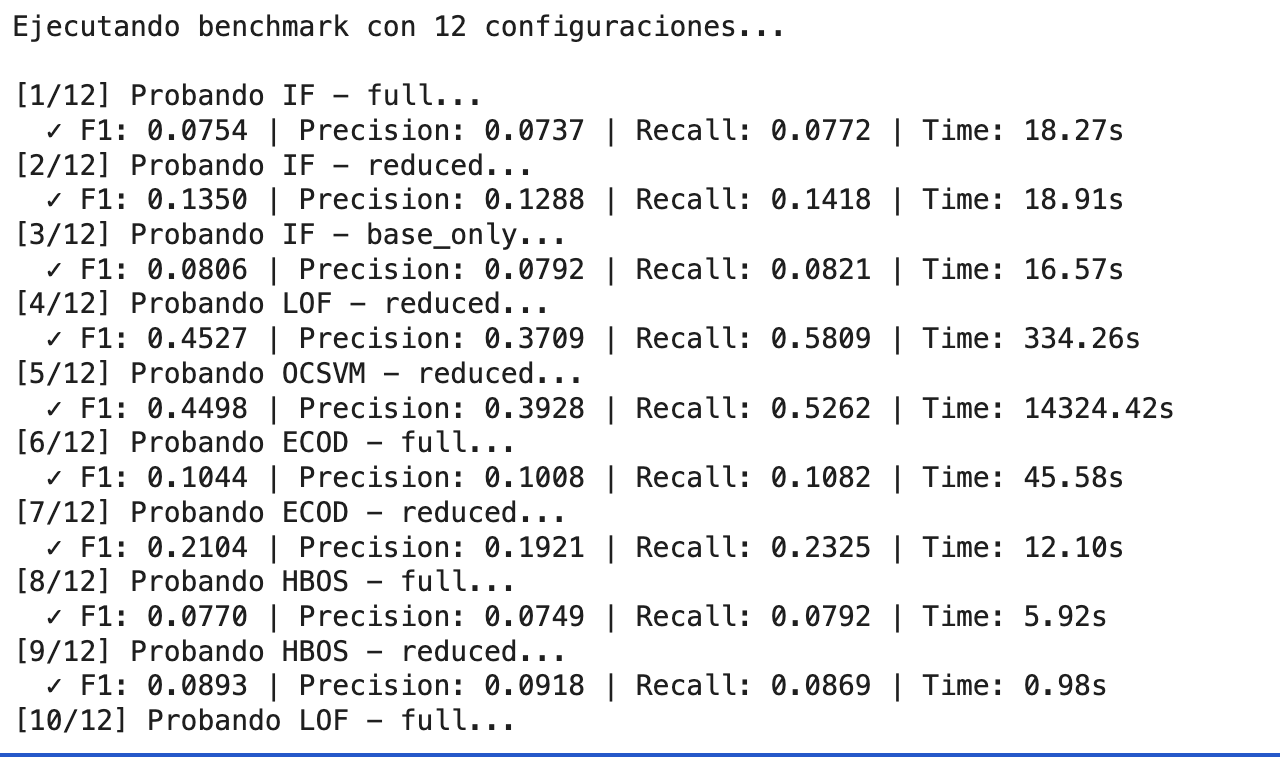

Los resultados del benchmark muestran que LOF y OCSVM presentan un rendimiento muy similar en términos de F1-score (0.45 frente a 0.44). Sin embargo, OCSVM presenta un coste computacional extremadamente elevado, siendo aproximadamente dos órdenes de magnitud más lento que LOF.

Dado que uno de los objetivos del sistema es su posible aplicación en entornos cercanos a tiempo real, se descarta OCSVM y se selecciona LOF como modelo final, al ofrecer el mejor compromiso entre rendimiento y eficiencia.

Para evaluar y comparar los detectores se utilizarán las siguientes métricas:

- **F1-score**: Métrica principal (media armónica de precisión y recall)
- **Precision**: Capacidad de no generar falsas alarmas
- **Recall**: Capacidad de detectar anomalías reales
- **AUC-ROC**: Capacidad discriminativa global
- **Tiempo de entrenamiento**: Escalabilidad del método
- **Tiempo de inferencia**: Adecuación para sistemas en tiempo real

La métrica principal será el **F1-score**, al ser la más adecuada para problemas
con desbalanceo de clases (típico en detección de anomalías).

Las anomalías en AIS presentan un carácter local, lo que explica el mejor rendimiento de LOF frente a Isolation Forest.


Métodos más complejos como OCSVM no aportan mejoras significativas respecto a LOF, pero sí incrementan drásticamente el coste computacional.

## Mejorar modelo (LOF + ENSEMBLE)

La combinación de modelos permite mejorar la detección de anomalías, especialmente en aquellos casos donde los patrones son locales o sutiles.

LOF: Local Outlier Factor

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

X_train = train_df[final_features]
X_holdout = holdout_df[final_features]

scaler_lof = StandardScaler()
X_train_scaled = scaler_lof.fit_transform(X_train)
X_holdout_scaled = scaler_lof.transform(X_holdout)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.06,
    novelty=True
)

lof.fit(X_train_scaled)

lof_scores = lof.decision_function(X_holdout_scaled)
lof_pred = (lof.predict(X_holdout_scaled) == -1).astype(int)

holdout_df["lof_score"] = lof_scores
holdout_df["lof_pred"] = lof_pred

Métricas LOF

In [ ]:
print(classification_report(
    holdout_df["is_synthetic"],
    holdout_df["lof_pred"],
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96    147539
           1       0.37      0.59      0.45      8850

    accuracy                           0.92    156389
   macro avg       0.67      0.76      0.71    156389
weighted avg       0.94      0.92      0.93    156389



Ensemble:

In [ ]:
holdout_df["if_pred"] = holdout_scored["pred_final"]

# voto OR → más recall
holdout_df["ensemble_pred"] = (
    (holdout_df["if_pred"] == 1) |
    (holdout_df["lof_pred"] == 1)
).astype(int)

Métricas ensemble

In [ ]:
print(classification_report(
    holdout_df["is_synthetic"],
    holdout_df["ensemble_pred"],
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93    147539
           1       0.25      0.65      0.37      8850

    accuracy                           0.87    156389
   macro avg       0.62      0.77      0.65    156389
weighted avg       0.94      0.87      0.90    156389



Ensemble detecta muchas pero con muchos falsos positivos.

**Conclusión:**

El modelo LOF presenta un equilibrio significativamente superior entre precisión y recall en comparación con Isolation Forest, lo que indica una mejor capacidad para detectar anomalías locales características del dominio marítimo.

## Análisis de anomalías detectads

In [ ]:
detected_anomalies = holdout_scored[holdout_scored["pred_final"] == 1].copy()

print("Número de anomalías detectadas:", len(detected_anomalies))
detected_anomalies

Número de anomalías detectadas: 9678


,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,...,slow_motion,high_speed_flag,low_distance_flag,is_synthetic,anomaly_type,anomaly_score,prediction,predicted_anomaly,pred_default,pred_final
124152,662164,367388450,12,5.793333,0.540946,7.300000,27.021429,150.9,0.728779,5.203448,...,0,0,0,0,normal,-0.093881,-1,1,1,1
298910,1407683,370188000,0,14.520414,0.094682,14.681915,0.688889,2.6,0.006743,0.016250,...,0,1,0,1,speed_anomaly,-0.023929,1,0,1,1
85147,453014,366992040,3,0.607143,2.189085,8.500000,28.938462,161.2,0.955405,8.484211,...,1,0,0,0,normal,-0.112650,-1,1,1,1
179071,925589,367690950,0,1.611111,2.131481,5.700000,47.125000,156.0,0.717116,3.120000,...,0,0,1,0,normal,-0.069799,-1,1,1,1
119276,636949,367350460,0,0.200000,0.086603,0.300000,31.800000,95.8,0.490050,1.388406,...,1,0,1,0,normal,-0.025545,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178848,925010,367690000,0,13.390000,0.070000,13.500000,1.155556,2.5,0.014556,0.032857,...,0,0,0,0,normal,-0.011161,1,0,1,1
11887,63378,310764000,2,17.172727,0.044536,17.200000,0.770000,1.9,0.010445,0.028358,...,0,0,0,0,normal,-0.015795,1,0,1,1
257518,1332385,368351530,0,0.021429,0.041033,0.100000,113.692308,179.2,1.683438,2.729508,...,1,0,1,0,normal,-0.000679,1,0,1,1
151784,787879,367537710,3,0.000000,0.000000,0.000000,23.850000,30.0,0.163260,0.201408,...,1,0,0,0,normal,-0.030467,1,0,1,1


Distribución por tipo

In [ ]:
detected_anomalies["anomaly_type"].value_counts(normalize=True)

,proportion
anomaly_type,
normal,0.872288
close_approach,0.026142
loitering_like,0.025522
speed_anomaly,0.023042
ais_gap_anomaly,0.021079
zigzag_anomaly,0.018289
route_deviation,0.013639


La mayoría de lo detectado son falsos positivos.

En copmparación con el anterior modelo, este detecta más la anomalía de close_approach, sin embargo speed_anomaly debería ser de las más detectables y aquí está establecido como "normalito".

El modelo está detectando más anomalías de tipo lentas/locales y menos las de tipo trayectoria.

Esto sugiere que las variables utilizadas capturan mejor características locales del movimiento, mientras que las anomalías relacionadas con la dinámica de la trayectoria requieren representaciones más complejas o modelos secuenciales.

In [ ]:
cols = [
    "speed_mean",
    "delta_course_mean",
    "turning_rate_mean",
    "distance_km",
    "duration",
    "ais_gap"
]

detected_anomalies.groupby("anomaly_type")[cols].mean()

,speed_mean,delta_course_mean,turning_rate_mean,distance_km,duration,ais_gap
anomaly_type,,,,,,
ais_gap_anomaly,5.212400,32.681561,0.431542,5.445396,735.642157,5.001087
close_approach,3.006574,23.071088,0.453739,1.485554,1139.331512,1.750952
loitering_like,3.391284,13.718213,0.248590,5.711255,1153.973676,1.818408
normal,5.857751,36.440827,0.585059,14.264482,703.821251,2.499094
route_deviation,3.999048,82.253924,1.074934,4.257918,731.143939,2.149960
speed_anomaly,10.406284,27.326030,0.375067,4.443778,754.860987,2.017673
zigzag_anomaly,3.504779,103.781825,1.507719,7.801300,756.344633,2.076151


Aunque el modelo no logra una clasificación perfecta, sí permite identificar segmentos con comportamientos significativamente distintos del patrón dominante, lo que constituye una base adecuada para etapas posteriores de análisis como clustering e interpretación de patrones.

In [ ]:
normal_sample = holdout_scored[
    (holdout_scored["pred_final"] == 0)
].sample(len(detected_anomalies), random_state=42)

comparison_df = pd.concat([
    detected_anomalies.assign(type="detected"),
    normal_sample.assign(type="normal")
])

comparison_df.groupby("type")[cols].mean()

,speed_mean,delta_course_mean,turning_rate_mean,distance_km,duration,ais_gap
type,,,,,,
detected,5.743087,37.078580,0.588520,13.045255,729.875012,2.491313
normal,1.059792,15.579946,0.157508,0.442808,767.375494,1.416128


Parece ser que el modelo está aprendiendo que lo raro se trata de un movimiento activo mientras que lo raro de verdad es comportamiento ilegal.

El modelo tiende a identificar como anómalos aquellos segmentos con mayor actividad dinámica, lo que indica que está capturando diferencias de intensidad de movimiento más que comportamientos ilegales específicos.

## Guardado del dataset

In [ ]:
final_pred_col = "lof_pred"

Extraemos anomalías finales

In [ ]:
final_anomalies = holdout_df[
    holdout_df[final_pred_col] == 1
].copy()

print("Final anomalies:", len(final_anomalies))

Final anomalies: 13985


In [ ]:
final_anomalies

,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,...,low_distance_flag,is_synthetic,anomaly_type,anomaly_score,prediction,predicted_anomaly,lof_score,lof_pred,if_pred,ensemble_pred
245332,1257735,368263020,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,0,normal,0.215718,1,0,-5.940759,1,0,1
251263,1291269,368300510,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,0,normal,0.214070,1,0,-12.727758,1,0,1
230581,1177212,368169220,2,0.000000,0.000000,0.000000,2.083333,5.300000,0.023264,0.065432,...,1,0,normal,0.186782,1,0,-0.418767,1,0,1
220668,1133371,368122650,0,0.008333,0.027639,0.100000,0.000000,0.000000,0.000000,0.000000,...,1,0,normal,0.143403,1,0,-4.760380,1,0,1
239985,1229152,368229380,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,0,normal,0.214713,1,0,-0.016076,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88434,469780,366999509,0,0.060000,0.080000,0.200000,57.475000,163.300000,0.359524,1.046795,...,1,0,normal,0.093541,1,0,-1.960766,1,0,1
301681,794556,367546890,0,0.004481,0.033072,0.036454,25.285714,177.000000,0.120408,0.842857,...,1,1,loitering_like,0.057927,1,0,-64.744849,1,0,1
270710,1385684,369155000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,0,normal,0.222671,1,0,-0.033947,1,0,1
309139,152818,338039852,0,0.160000,0.120000,0.400000,6.033977,5.345902,0.009215,0.029699,...,1,1,zigzag_anomaly,0.115388,1,0,-2.711285,1,0,1


In [ ]:
final_anomalies['anomaly_type'].value_counts()

,count
anomaly_type,
normal,8793
close_approach,1367
loitering_like,1364
speed_anomaly,1217
zigzag_anomaly,564
route_deviation,450
ais_gap_anomaly,230


Lo guardamos

In [ ]:
final_anomalies.to_csv(
    base_path + "final_anomalies_LOF.csv",
    index=False
)

Preparamos la matriz

In [ ]:
X_final = final_anomalies[final_features]

scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

Las anomalías detectadas no constituyen ground truth real, sino candidatos a comportamiento anómalo identificados mediante técnicas no supervisadas.

## Limitaciones del enfoque



1. El modelo LOF detecta mejor anomalías locales (por ejemplo loitering_like o close_approach)
   que anomalías globales de trayectoria (por ejemplo route_deviation o zigzag).

2. La tasa de falsos positivos sigue siendo relevante: una parte importante de los segmentos
   detectados como anómalos pertenecen a la clase normal, lo que indica que el modelo está
   capturando comportamiento raro estadísticamente, no necesariamente ilegal o sospechoso.

3. Esto refuerza la necesidad de un enfoque híbrido:
   - un detector estadístico para filtrar candidatos
   - y un análisis posterior (clustering, reglas marítimas, ranking) para interpretar riesgo.
